# 04 — Time Series EDA
**Explorar la dimensión temporal de los datos.**

Antes de modelar series de tiempo, hay que entender su estructura:

## Componentes de una serie de tiempo
$$Y_t = T_t + S_t + C_t + R_t$$
- **$T_t$ Tendencia**: dirección de largo plazo (crecimiento, decrecimiento)
- **$S_t$ Estacionalidad**: patrones que se repiten con frecuencia fija (día de semana, mes)
- **$C_t$ Ciclo**: fluctuaciones de largo plazo sin período fijo
- **$R_t$ Residual**: ruido no explicado por los otros componentes

## Preguntas clave en EDA temporal
1. ¿Hay tendencia? ¿Creciente, decreciente, quiebre?
2. ¿Hay estacionalidad? ¿Día de semana, hora, mes?
3. ¿Hay anomalías o picos? ¿Correlacionan con eventos externos?
4. ¿La serie es estacionaria? (relevante para modelos ARIMA)

In [6]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

rng = np.random.default_rng(42)
n = 5000

dates      = pd.date_range('2023-01-01', periods=n, freq='2h') + pd.to_timedelta(rng.integers(0, 120, n), unit='m')
categories = rng.choice(['Electronics','Clothing','Home','Sports','Books','Beauty'], n, p=[0.25,0.22,0.18,0.15,0.12,0.08])
channels   = rng.choice(['organic','paid','email','direct','affiliate'], n, p=[0.30,0.25,0.20,0.15,0.10])
price      = np.where(categories=='Electronics', rng.lognormal(4.5,0.8,n),
             np.where(categories=='Clothing',    rng.lognormal(3.5,0.6,n),
                                                 rng.lognormal(3.2,0.7,n))).round(2)
qty        = rng.integers(1, 8, n)
discount   = np.where(rng.uniform(0,1,n)<0.3, rng.uniform(0.05,0.40,n), 0.0).round(2)
revenue    = (price * qty * (1 - discount)).round(2)

df = pd.DataFrame({
    'date': dates, 'category': categories, 'channel': channels,
    'price': price, 'quantity': qty, 'discount': discount, 'revenue': revenue,
})
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Extraer componentes temporales
df['date_day']  = df['date'].dt.date
df['week']      = df['date'].dt.isocalendar().week.astype(int)
df['month']     = df['date'].dt.month
df['dow']       = df['date'].dt.dayofweek      # 0=lunes
df['dow_name']  = df['date'].dt.day_name()
df['hour']      = df['date'].dt.hour

print(f'Rango temporal: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Órdenes totales: {len(df):,}')

Rango temporal: 2023-01-01 → 2024-02-21
Órdenes totales: 5,000


## 1 — Tendencia: revenue diario con media móvil

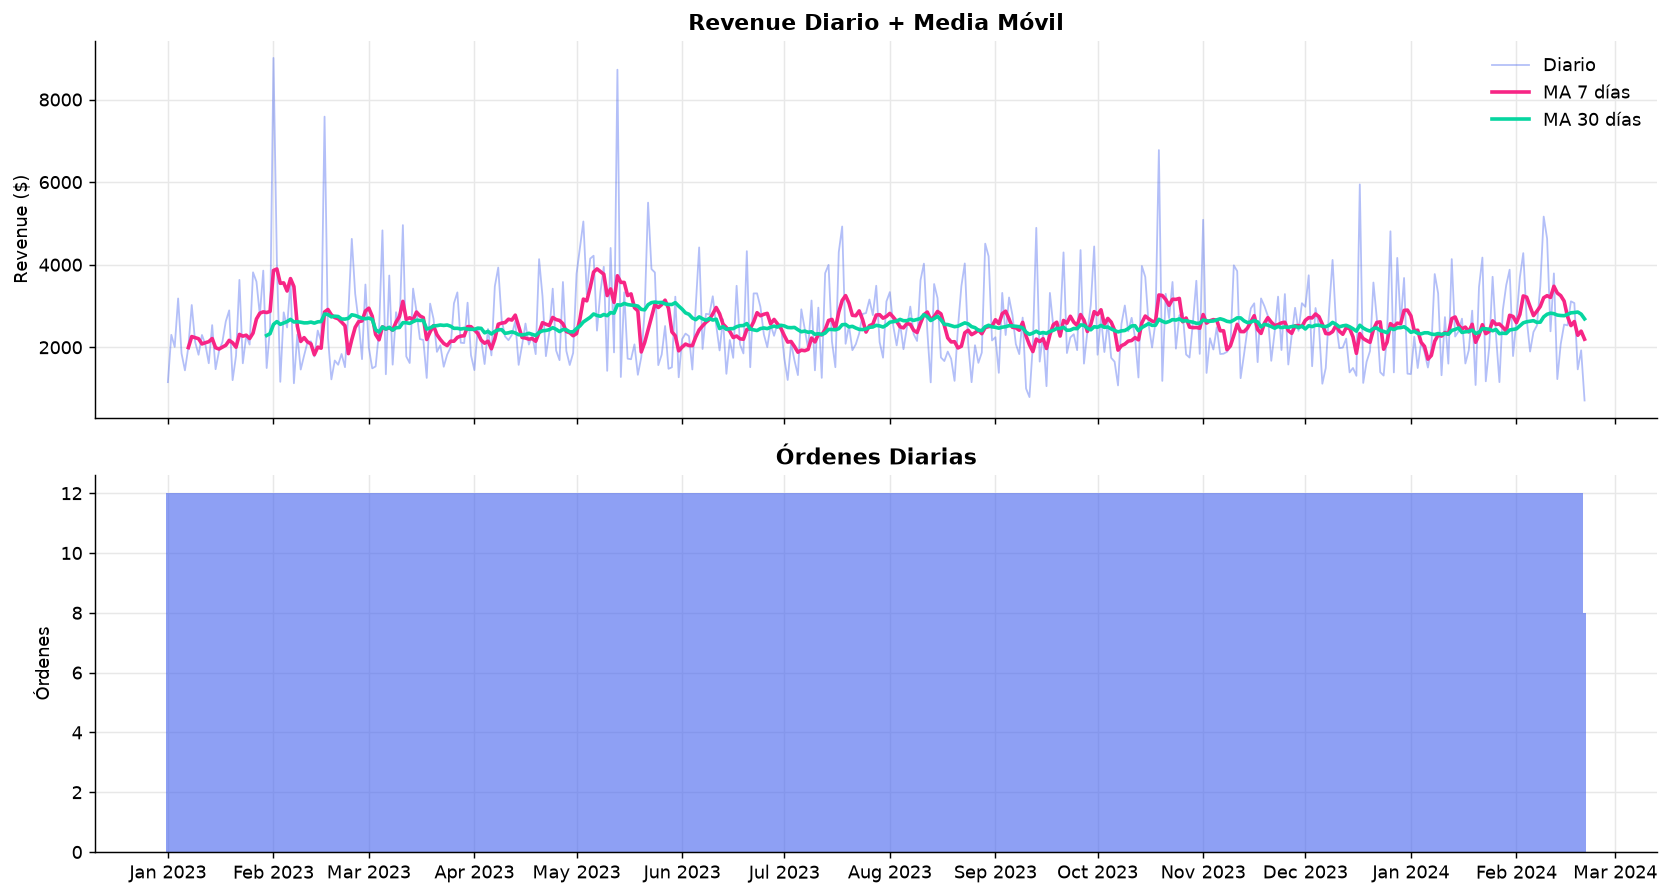

Tendencia lineal: slope=0.0 $/día  r=0.005  p=0.9149
→ No hay tendencia significativa.


In [7]:
daily = df.groupby('date_day').agg(
    revenue=('revenue', 'sum'),
    orders=('revenue', 'count'),
).reset_index()
daily['date_day'] = pd.to_datetime(daily['date_day'])
daily['ma7']  = daily['revenue'].rolling(7).mean()
daily['ma30'] = daily['revenue'].rolling(30).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(daily['date_day'], daily['revenue'], color='#4361ee', alpha=0.4, linewidth=1, label='Diario')
axes[0].plot(daily['date_day'], daily['ma7'],     color='#f72585', linewidth=2, label='MA 7 días')
axes[0].plot(daily['date_day'], daily['ma30'],    color='#06d6a0', linewidth=2, label='MA 30 días')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Revenue Diario + Media Móvil')
axes[0].legend()

axes[1].bar(daily['date_day'], daily['orders'], color='#4361ee', alpha=0.6, width=1)
axes[1].set_ylabel('Órdenes')
axes[1].set_title('Órdenes Diarias')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

# Tendencia lineal
x = np.arange(len(daily))
slope, intercept, r, p, _ = stats.linregress(x, daily['revenue'])
print(f'Tendencia lineal: slope={slope:.1f} $/día  r={r:.3f}  p={p:.4f}')
print('→ slope > 0 y p < 0.05: revenue creciente de forma estadísticamente significativa.' if p < 0.05 else '→ No hay tendencia significativa.')

## 2 — Estacionalidad: día de semana y hora

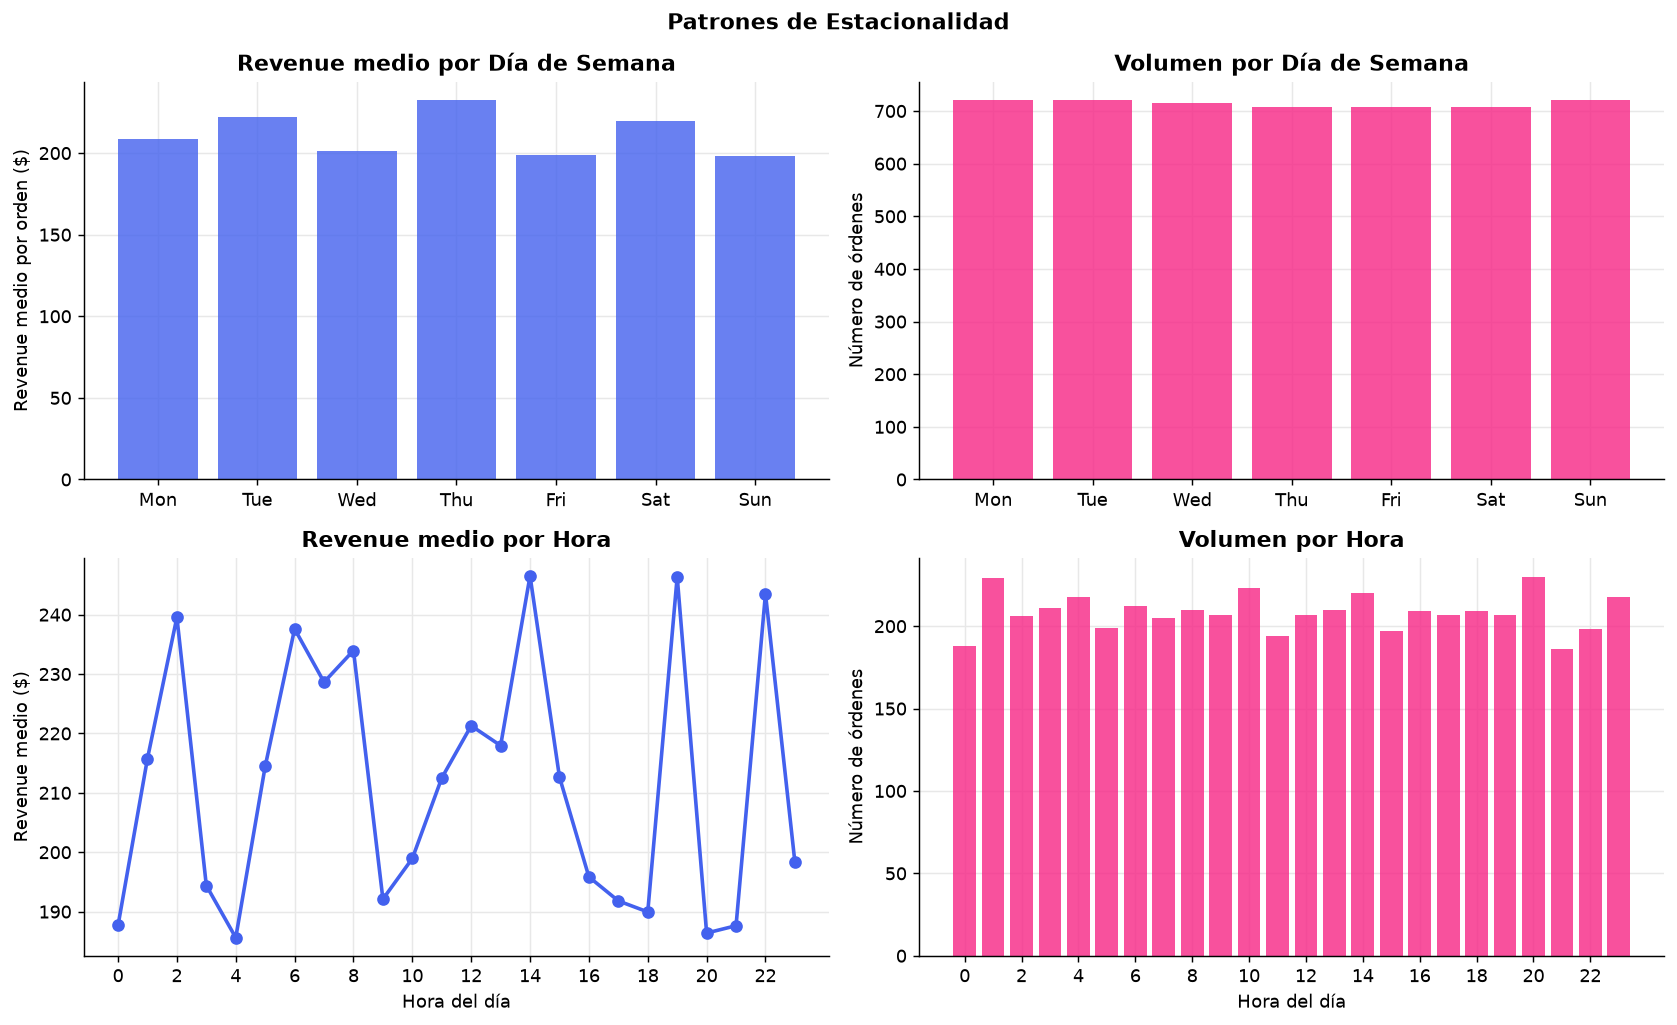

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Órdenes por día de semana
dow_rev = df.groupby('dow_name')['revenue'].agg(['mean','sum','count'])
dow_rev = dow_rev.reindex(dow_order)
axes[0,0].bar(range(7), dow_rev['mean'], color='#4361ee', alpha=0.8)
axes[0,0].set_xticks(range(7))
axes[0,0].set_xticklabels([d[:3] for d in dow_order])
axes[0,0].set_ylabel('Revenue medio por orden ($)')
axes[0,0].set_title('Revenue medio por Día de Semana')

# Órdenes por día de semana
axes[0,1].bar(range(7), dow_rev['count'], color='#f72585', alpha=0.8)
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels([d[:3] for d in dow_order])
axes[0,1].set_ylabel('Número de órdenes')
axes[0,1].set_title('Volumen por Día de Semana')

# Revenue por hora
hour_rev = df.groupby('hour')['revenue'].agg(['mean','count'])
axes[1,0].plot(hour_rev.index, hour_rev['mean'], 'o-', color='#4361ee', linewidth=2)
axes[1,0].set_xlabel('Hora del día')
axes[1,0].set_ylabel('Revenue medio ($)')
axes[1,0].set_title('Revenue medio por Hora')
axes[1,0].set_xticks(range(0, 24, 2))

axes[1,1].bar(hour_rev.index, hour_rev['count'], color='#f72585', alpha=0.8)
axes[1,1].set_xlabel('Hora del día')
axes[1,1].set_ylabel('Número de órdenes')
axes[1,1].set_title('Volumen por Hora')
axes[1,1].set_xticks(range(0, 24, 2))

plt.suptitle('Patrones de Estacionalidad', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 — Heatmap temporal: hora × día de semana

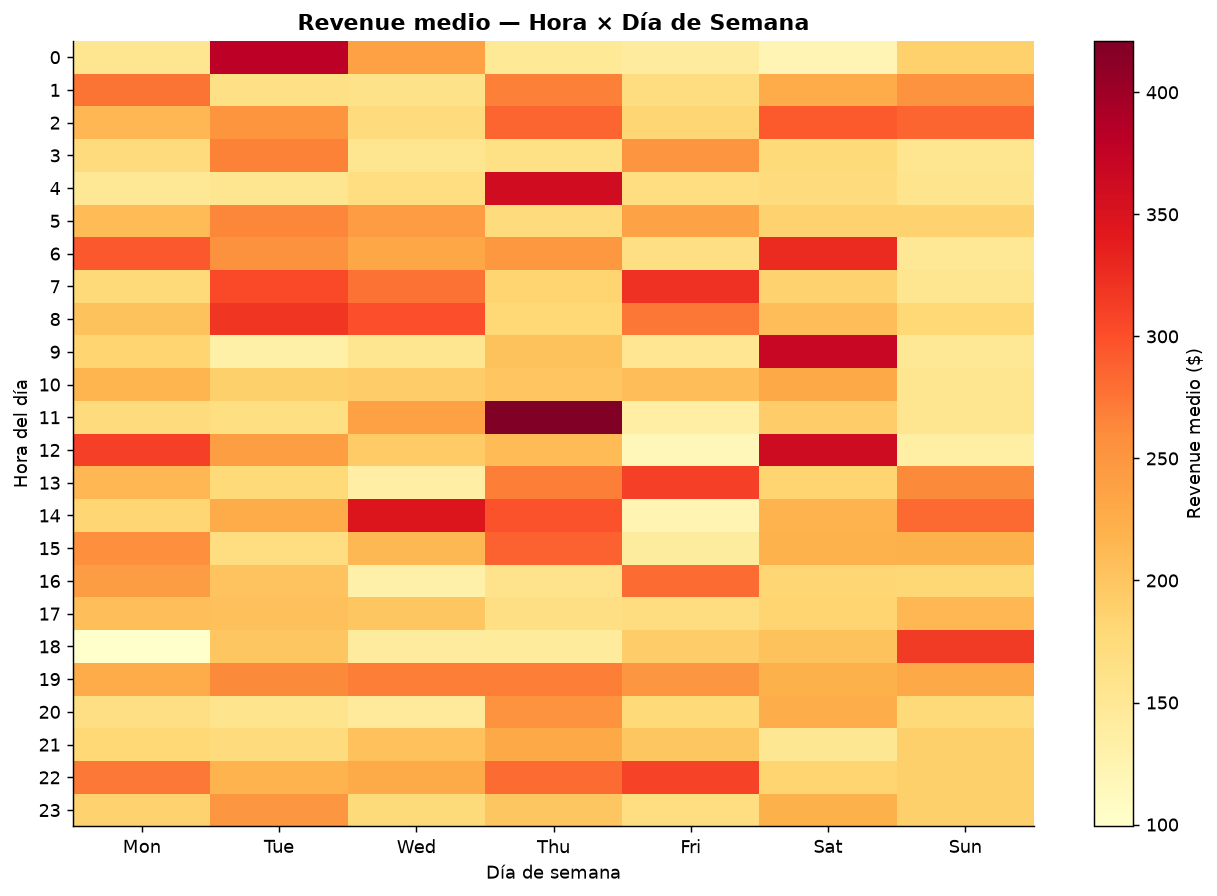

Este heatmap revela simultáneamente estacionalidad semanal e intradiaria.


In [9]:
pivot = df.pivot_table(values='revenue', index='hour', columns='dow', aggfunc='mean')
pivot.columns = [dow_order[i][:3] for i in pivot.columns]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(7))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(24))
ax.set_yticklabels(range(24))
ax.set_xlabel('Día de semana')
ax.set_ylabel('Hora del día')
ax.set_title('Revenue medio — Hora × Día de Semana')
ax.grid(False)
plt.colorbar(im, ax=ax, label='Revenue medio ($)')
plt.tight_layout()
plt.show()
print('Este heatmap revela simultáneamente estacionalidad semanal e intradiaria.')

## 4 — Descomposición de tendencia y estacionalidad

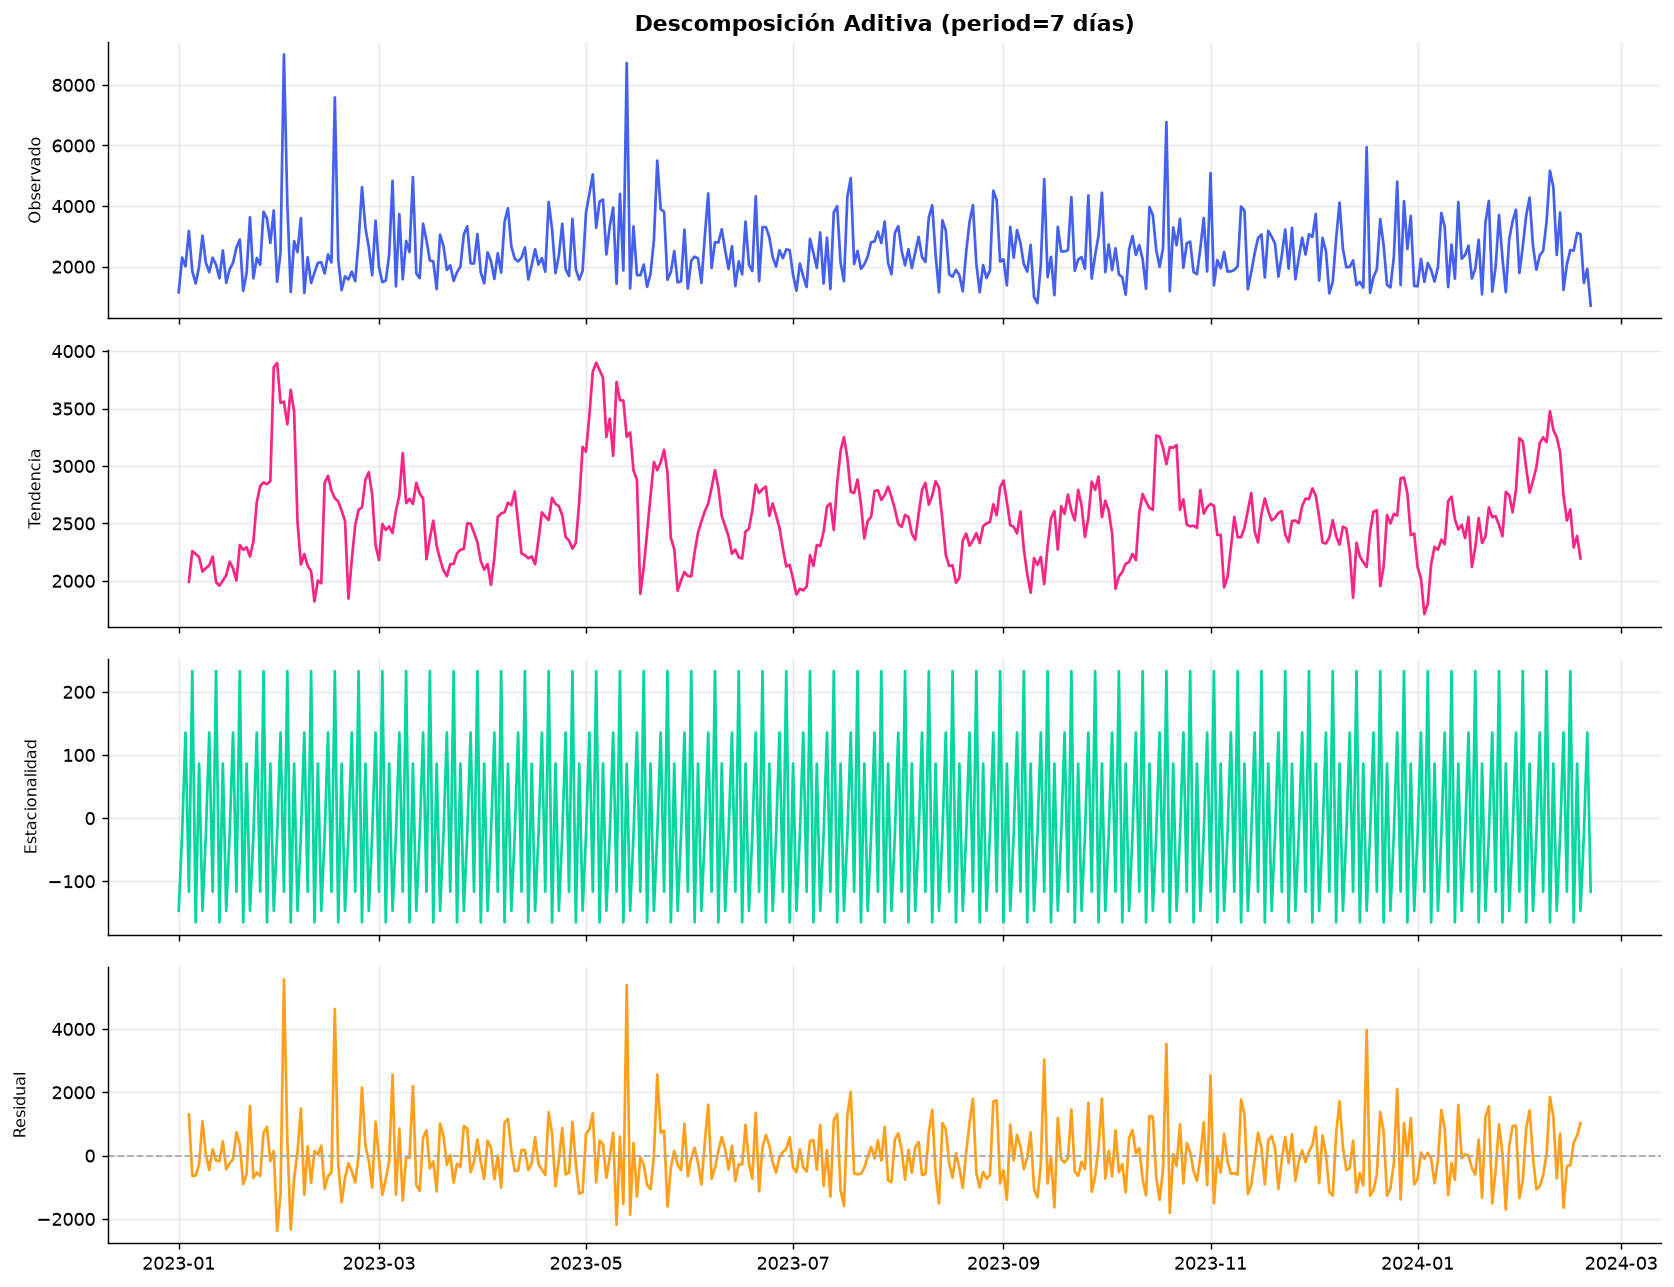

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Agregar a nivel diario para descomposición
daily_rev = df.groupby('date_day')['revenue'].sum()
daily_rev.index = pd.to_datetime(daily_rev.index)
daily_rev = daily_rev.asfreq('D').ffill()   # fillna(method=) removido en pandas 2.0

decomp = seasonal_decompose(daily_rev, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
components = [
    (daily_rev,          'Observado',     '#4361ee'),
    (decomp.trend,       'Tendencia',     '#f72585'),
    (decomp.seasonal,    'Estacionalidad','#06d6a0'),
    (decomp.resid,       'Residual',      '#ff9f1c'),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1.5)
    if label == 'Residual':
        ax.axhline(0, color='#aaa', linestyle='--', linewidth=1)
    ax.set_ylabel(label, fontsize=9)

axes[0].set_title('Descomposición Aditiva (period=7 días)')
plt.tight_layout()
plt.show()

## 5 — Revenue por categoría a lo largo del tiempo

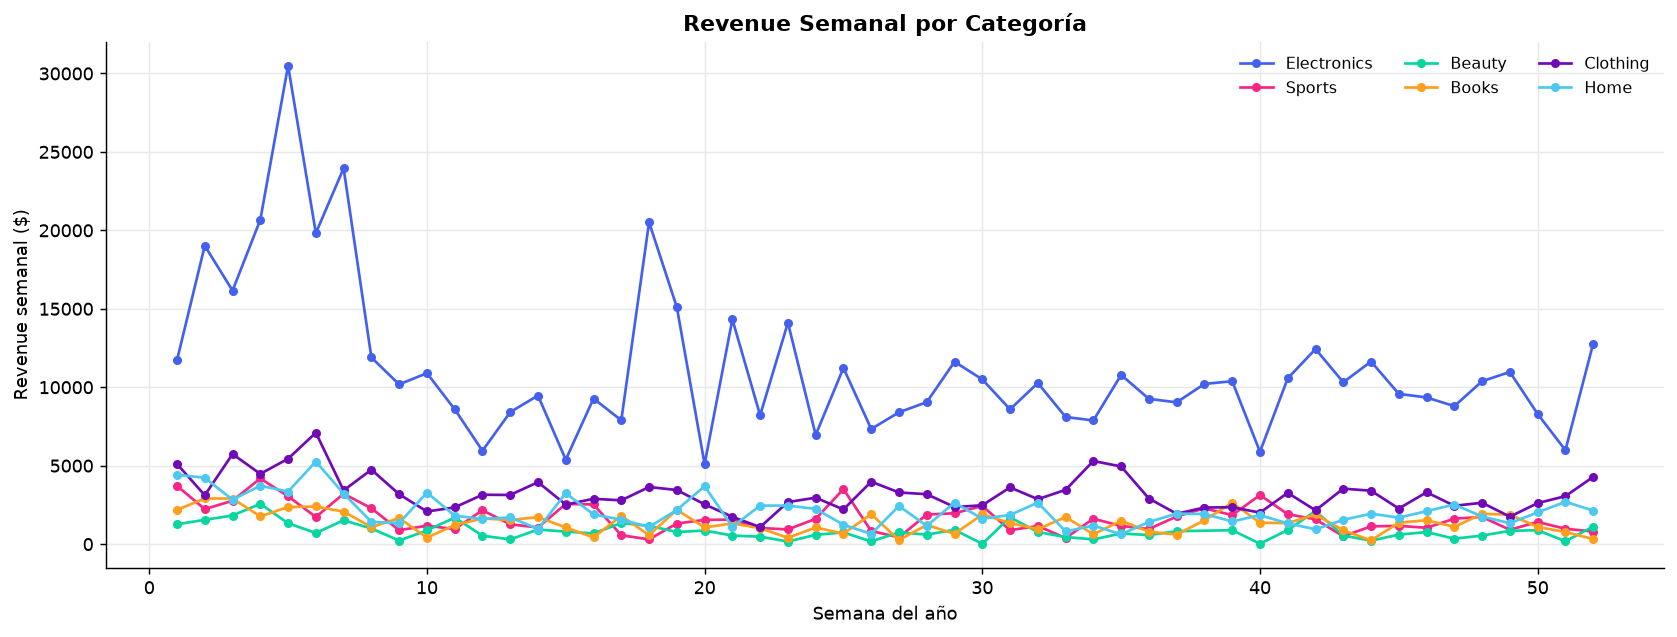

In [11]:
weekly_cat = df.groupby(['week', 'category'])['revenue'].sum().reset_index()
colors = ['#4361ee','#f72585','#06d6a0','#ff9f1c','#7209b7','#4cc9f0']
cat_list = df['category'].unique()

fig, ax = plt.subplots(figsize=(13, 5))
for cat, color in zip(cat_list, colors):
    d = weekly_cat[weekly_cat['category'] == cat]
    ax.plot(d['week'], d['revenue'], 'o-', color=color, linewidth=1.5, markersize=4, label=cat)

ax.set_xlabel('Semana del año')
ax.set_ylabel('Revenue semanal ($)')
ax.set_title('Revenue Semanal por Categoría')
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

## Resumen

| Análisis | Herramienta | Qué revela |
|---|---|---|
| Tendencia | Serie + MA + regresión lineal | Dirección de largo plazo |
| Estacionalidad semanal | Agrupar por `day_name` | Picos de venta por día |
| Estacionalidad intradiaria | Agrupar por `hour` | Horas pico |
| Doble estacionalidad | Heatmap hora × día | Patrones combinados |
| Descomposición formal | `seasonal_decompose` | Separar tendencia, estacionalidad y ruido |

**Siguiente:** `05_missing_data.ipynb`